The previous tests showed that it didnt gain much performance so will try to make use of a larger model, but with no data augmentation and the original image size.

Prerequisits

In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Libraries needed

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Paths to dataset

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV created from your local preparation script
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())

df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())

Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Settings

In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH  = 480
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
EPOCHS     = 300

Data loading

In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)   # keep in [0,255]
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe, batch_size=8, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Model architecture

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S

base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# First stage: freeze pretrained backbone
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# Forward pass through pretrained backbone
x = base_model(inputs, training=False)

# Head for regression
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(inputs, outputs, name="efficientnetv2s_rgb_pretrained_carb_regression_model_2_5_V2")
model.summary()

Model: "efficientnetv2s_rgb_pretrained_carb_regression_model_2_5_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 640, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 20, 15, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,692,321 (78.93 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 463.7965 - mae: 13.2723 - mse: 463.7965   
Epoch 1: val_loss improved from None to 132.73610, saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - loss: 501.6316 - mae: 11.3333 - mse: 501.6316 - val_loss: 132.7361 - val_mae: 8.3508 - val_mse: 132.7361 - learning_rate: 0.0010
Epoch 2/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 379.7410 - mae: 8.6052 - mse: 379.7410
Epoch 2: val_loss improved from 132.73610 to 129.07513, saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_mode

Plotting training and validation

In [ ]:
def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

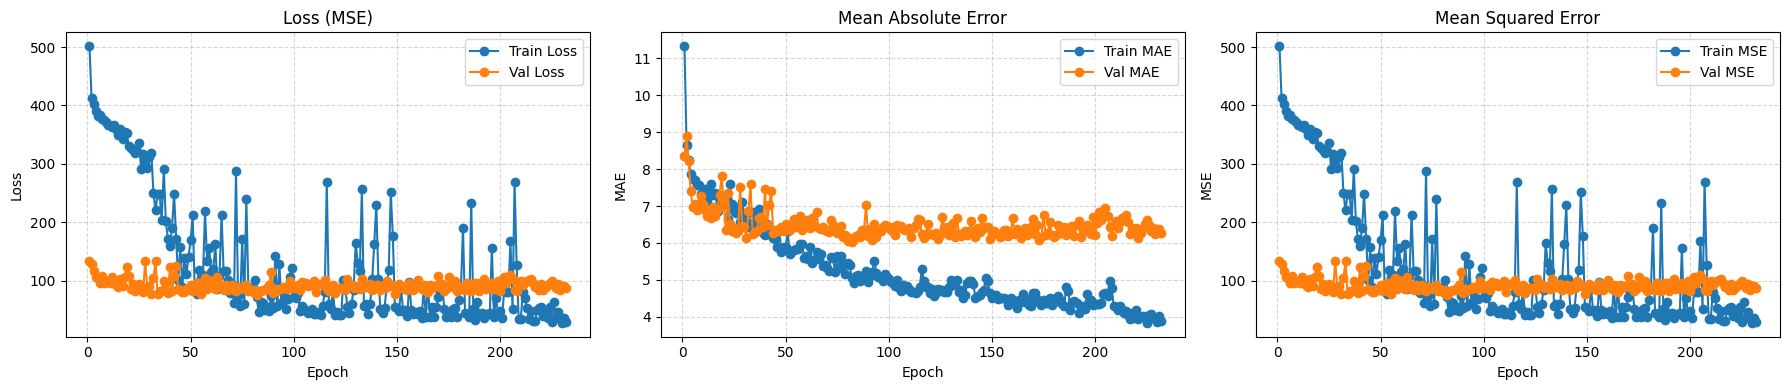

Best val_loss: 75.2126 at epoch 82
Val MAE at best epoch: 6.0377
Val MSE at best epoch: 75.2126


In [ ]:
plot_metrics(history)

Testing model on test dataset

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"), compile=False)

In [ ]:
loaded_model_test_results = loaded_model.evaluate(test_dataset, return_dict=True)
print(loaded_model_test_results)

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - loss: 85.1922 - mae: 6.0945 - mse: 85.1922
{'loss': 85.19216918945312, 'mae': 6.094511985778809, 'mse': 85.19216918945312}


Stage 2 training (unfreezing more layers)

In [ ]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 120

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Freeze BatchNormalization layers for stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total layers in base_model:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)

trainable_count = np.sum([layer.trainable for layer in base_model.layers])
print("Trainable layers in base_model:", trainable_count)

Total layers in base_model: 513
Fine-tuning from layer index: 393
Trainable layers in base_model: 96


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2_finetuned.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
EPOCHS_STAGE2 = 300

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_STAGE2,
    callbacks=stage2_callbacks
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 43.7359 - mae: 4.4754 - mse: 43.7359
Epoch 1: val_loss improved from None to 79.94135, saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model_stage2_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model_stage2_finetuned.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - loss: 41.0309 - mae: 4.4055 - mse: 41.0309 - val_loss: 79.9413 - val_mae: 6.0102 - val_mse: 79.9413 - learning_rate: 1.0000e-05
Epoch 2/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 39.7081 - mae: 4.3931 - mse: 39.7081
Epoch 2: val_loss did not improve from 79.94135
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - loss: 47.7725 - mae: 4.4292 - mse: 47.7725 - val_loss: 81.4325 - val_mae: 6.0223 - val_mse: 81.4325 - learning_rate: 1.0000e-05
Epoch 3/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 34.27

Plotting stage 2

In [ ]:
def plot_metrics(history, title="Training history"):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title(f"{title} - Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title(f"{title} - Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title(f"{title} - Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")
    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

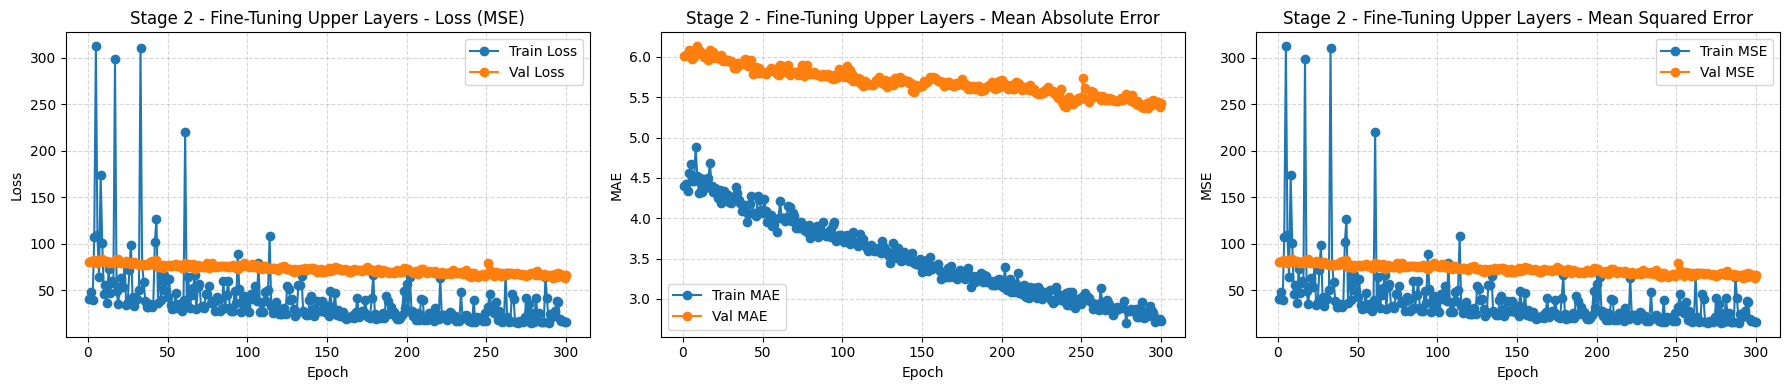

Best val_loss: 63.2617 at epoch 299
Val MAE at best epoch: 5.3806
Val MSE at best epoch: 63.2617


In [ ]:
plot_metrics(history_stage2, title="Stage 2 - Fine-Tuning Upper Layers")

Testing on test set

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 692ms/step - loss: 66.1927 - mae: 5.3145 - mse: 66.1927
{'loss': 66.19270324707031, 'mae': 5.314505577087402, 'mse': 66.19270324707031}
